
#PyTorch Basics: Deep Learning & Data Analysis

**Over the next few weeks we will learn the basics of Deep Learning using pytorch**

Do the coding exercises below, add comments and markdown explanations, and upload the resulting notebook together with the collab corresponding to mini project 2.

This notebook covers:

1. Problem setup & data splits (train/val/test)  
2. PyTorch tensors, datasets, and dataloaders  
3. Models: linear regression, MLP for classification, CNN
4. Losses, regularization (L2/weight decay & dropout), and metrics  
5. Optimization: gradient descent w/ `torch.optim`   
6. Experiment tracking: random seeds, reproducibility, and plotting learning curves  

> This notebook uses only standard libraries available in Colab: `torch`, `numpy`, `matplotlib`, and the `sklearn` library for toy data.


In [1]:
!pip install -q torch torchvision torchaudio


In [2]:
#@title Imports & reproducibility helpers
import math, random, os, time
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from typing import Tuple, Dict, Any

try:
    from sklearn.datasets import make_moons, make_circles
    _HAS_SKLEARN = True
except Exception as e:
    print("scikit-learn not found; synthetic dataset generators will fall back to torch-only.")
    _HAS_SKLEARN = False

import matplotlib.pyplot as plt

def set_seed(seed: int = 123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(7)
DEVICE


'cpu'

#🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩

##-1) Tensors

Tensors in pytorch are very similar to numpy arrays

1. 🧩 How do we construct a tensor?

Say we want to construct the following tensor using torch functions:

```python
tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])
```

2. 🧩 What's the size of this tensor?


In [34]:
import torch

x = torch.arange(9).view(3, 3).t()
x


tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])

In [35]:
x.size()

torch.Size([3, 3])

In [5]:
#@title Pytorch has many useful functions for creating, indexing and operating with tensor
# Parameters
sequence = torch.arange(5)   # [0, 1, 2, 3, 4]
repeats = 3                  # number of times to repeat

# Construct the repeated tensor
x = sequence.repeat(repeats)

print(sequence), print(x)

tensor([0, 1, 2, 3, 4])
tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4])


(None, None)

In [6]:
#@title 🧩 Print a tensor of size (5,3), where all the values have one fixed size
torch.full((5,3), -2.0)

tensor([[-2., -2., -2.],
        [-2., -2., -2.],
        [-2., -2., -2.],
        [-2., -2., -2.],
        [-2., -2., -2.]])

###🧩 Construct* the following tensor:

```python
tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]])

At some point in my code, I need to write an equation that uses 2 * pi.
I get an error allerting  me that my code returns a float where a tensor is expected. What is the type of

```python
type(2*torch.py)
```
and how do I turn into a tensor?


In [7]:
#@title 🧩 Use pytorch functions to generate this matrix

n = 4
A = torch.eye(n)                         # diagonal of 1s
A += torch.diag(torch.full((n-1,), -2.), diagonal=-1)  # sub-diagonal
A += torch.diag(torch.full((n-1,), -2.), diagonal=1)   # super-diagonal

print(A)

tensor([[ 1., -2.,  0.,  0.],
        [-2.,  1., -2.,  0.],
        [ 0., -2.,  1., -2.],
        [ 0.,  0., -2.,  1.]])


#🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩


# 0) Broadcasting, Indexing, and Distributions in PyTorch

**Goal:** Practice *broadcasting*, *masking*, and *distributions* in PyTorch through short guided exercises.

Run each code cell, fill in the `# TODO` parts, and test your answers.


In [8]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt
torch.manual_seed(0)


## Broadcasting and Fancy Indexing

Broadcasting and indexing make PyTorch efficient and expressive.



### 🧩 Exercise 0.1  
Construct a tensor `X` where `X[i,j] = 2*i + j` using broadcasting.  

**Example Output:**
```
tensor([[0, 1, 2, 3],
        [2, 3, 4, 5],
        [4, 5, 6, 7]])
```


In [37]:
i = torch.arange(3).view(-1, 1)
j = torch.arange(4).view(1, -1)
X = 2 * i + j
X

tensor([[0, 1, 2, 3],
        [2, 3, 4, 5],
        [4, 5, 6, 7]])

### 🧩 Exercise 0.2  
Compute a **distance matrix** `D` where `D[i,j]` is the Euclidean distance between `X[i]` and `X[j]`.  

Use broadcasting (no loops).


In [39]:
X = torch.arange(12, dtype=float).reshape(6, 2)

diff = X[:, None, :] - X[None, :, :]        # shape: (6, 6, 2)
D = torch.sqrt(torch.sum(diff ** 2, dim=-1))
D

tensor([[ 0.0000,  2.8284,  5.6569,  8.4853, 11.3137, 14.1421],
        [ 2.8284,  0.0000,  2.8284,  5.6569,  8.4853, 11.3137],
        [ 5.6569,  2.8284,  0.0000,  2.8284,  5.6569,  8.4853],
        [ 8.4853,  5.6569,  2.8284,  0.0000,  2.8284,  5.6569],
        [11.3137,  8.4853,  5.6569,  2.8284,  0.0000,  2.8284],
        [14.1421, 11.3137,  8.4853,  5.6569,  2.8284,  0.0000]],
       dtype=torch.float64)


### 🧩 Exercise 0.3  
Extract the submatrix of rows `[1,4]` and columns `[0,2,3]` of  
`A = torch.arange(36).reshape(6, 6)`

**Expected Output:**
```
tensor([[ 6,  8,  9],
        [24, 26, 27]])
```


In [40]:
rows = torch.tensor([1, 4])
cols = torch.tensor([0, 2, 3])

subA = A[rows[:, None], cols]
subA

tensor([[ 6,  8,  9],
        [24, 26, 27]])


### 🧩 Exercise 0.4  
Create a **boolean mask** `M` where `M[i,j]` is True iff `A[i,j]` is divisible by 5 or 7.


In [41]:
M = (A % 5 == 0) | (A % 7 == 0)
print(M.sum())
M

tensor(12)


tensor([[ True, False, False, False, False,  True],
        [False,  True, False, False,  True, False],
        [False, False,  True,  True, False, False],
        [False, False,  True,  True, False, False],
        [False,  True, False, False,  True, False],
        [ True, False, False, False, False,  True]])


### 🧩 Exercise 0.5  
Using the mask `M`, add 10 to elements of `A` that are divisible by 5 or 7 (in-place).


In [44]:
A[M] += 10
print(A)

tensor([[10,  1,  2,  3,  4, 15],
        [ 6, 17,  8,  9, 20, 11],
        [12, 13, 24, 25, 16, 17],
        [18, 19, 30, 31, 22, 23],
        [24, 35, 26, 27, 38, 29],
        [40, 31, 32, 33, 34, 45]])



## Distributions

`torch.distributions` provides a clean API for probability distributions and supports broadcasting.



### 🧩 Exercise 0.6  
Draw **100 samples** from a Poisson distribution with rate λ = 4.5.


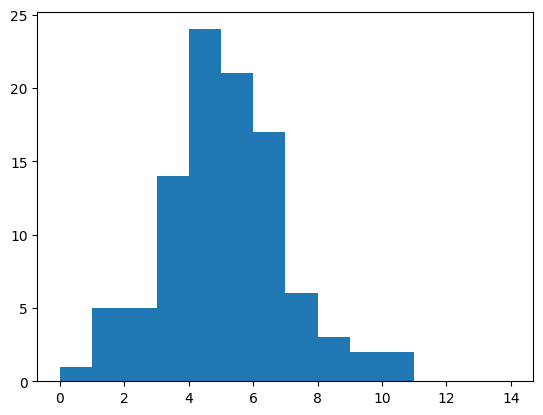

In [54]:
import torch.distributions as dist
import matplotlib.pyplot as plt
torch.manual_seed(0)

samples = dist.Poisson(4.5).sample((100,))

plt.hist(samples.numpy(), bins=range(0, 15))
plt.show()


### 🧩 🧩 Exercise 0.7  
Construct a matrix `P` where  
`P[i,j] = exp(-λ[i]) * λ[i]^j / j!`  
for λ = `torch.arange(1.,6.)` and j = `torch.arange(5.)`.


In [56]:
import torch

lam = torch.arange(1., 6.).view(-1, 1)
j = torch.arange(5.).view(1, -1)

factorial = torch.exp(torch.lgamma(j + 1))

P = torch.exp(-lam) * (lam ** j) / factorial

P

tensor([[0.3679, 0.3679, 0.1839, 0.0613, 0.0153],
        [0.1353, 0.2707, 0.2707, 0.1804, 0.0902],
        [0.0498, 0.1494, 0.2240, 0.2240, 0.1680],
        [0.0183, 0.0733, 0.1465, 0.1954, 0.1954],
        [0.0067, 0.0337, 0.0842, 0.1404, 0.1755]])


### 🧩 🧩 Exercise 0.8
Evaluate the **log-probability** of `[0.5, 2.0, 5.0]`  
under a Gamma distribution with shape=3.0, rate=2.0.


In [58]:
import torch
import torch.distributions as dist

g = dist.Gamma(concentration=3.0, rate=2.0)
logp = g.log_prob(torch.tensor([0.5, 2.0, 5.0]))
print(logp)

tensor([-1.0000, -1.2274, -5.3948])



### 🧩 Problem 0.9  
Draw **1000 samples** from a mixture of two Poisson distributions  
with rates 2 and 7, equal weights (0.5, 0.5).  
Plot a normalized histogram.


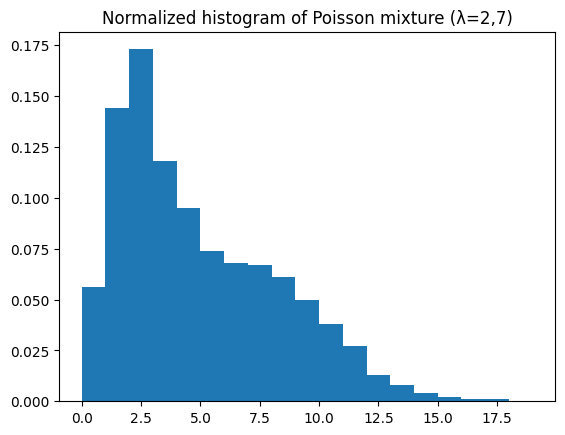

In [60]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

torch.manual_seed(0)

z = torch.bernoulli(torch.full((1000,), 0.5))   # 0 or 1, with prob 0.5

lam = torch.where(z.bool(), torch.tensor(7.), torch.tensor(2.))

samples = dist.Poisson(lam).sample()

plt.hist(samples.numpy(), bins=range(0, 20), density=True)
plt.title("Normalized histogram of Poisson mixture (λ=2,7)")
plt.show()


## Normal Distributions



### 🧩 Problem 0.10  
Use `dist.Normal` to draw a batch of shape `(200, 3)` of independent standard normal random variables.


In [61]:
import torch
import torch.distributions as dist

normals = dist.Normal(0, 1).sample((200, 3))
print(normals.shape)

torch.Size([200, 3])



### 🧩 Problem 0.11  
Use `dist.Normal` to draw a batch of shape `(4, 4)`  
with means given by `mu` and variance 1.0.


In [62]:
import torch
import torch.distributions as dist

mu = torch.tensor([
    [ 0,  1,  2,  3],
    [ 4,  5,  6,  7],
    [ 8,  9, 10, 11],
    [12, 13, 14, 15]
], dtype=torch.float32)

samples = dist.Normal(mu, 1.0).sample()   # 方差=1
print(samples.shape)
print(samples)

torch.Size([4, 4])
tensor([[ 0.0228,  1.4973,  2.6176,  0.9522],
        [ 4.9124,  5.9909,  5.2167,  5.9902],
        [ 9.0891,  8.7363, 10.0359, 11.3172],
        [11.5520, 14.2566, 14.4184, 14.3590]])



---
### ✅ Notes / Extensions

- Vary λ and j shapes to visualize broadcasting.  
- Plot distance matrices `plt.imshow(D)` to see patterns.  
- Compare the Poisson mixture histogram with theoretical PMFs.  
- Explore `dist.MixtureSameFamily` for more complex mixtures.


#🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩


# 1) Data: from arrays to `Dataset`/`DataLoader` + train/val/test split

**Key ideas**
- Always separate data into **train / validation / test** (e.g., 70/15/15).  
- Wrap arrays in a custom `Dataset` to keep the training loop clean.  
- Use a `DataLoader` for batching, shuffling, and parallel loading.

We'll start with toy 2D datasets for classification (moons and circles) and a simple 1D regression problem.


In [63]:

#@title Toy datasets (classification: moons/circles) + (regression: y = ax + b + noise)
def make_toy_classification(n_samples=1000, kind="moons", noise=0.2, seed=0):
    set_seed(seed)
    if _HAS_SKLEARN:
        if kind == "moons":
            X, y = make_moons(n_samples=n_samples, noise=noise)
        elif kind == "circles":
            X, y = make_circles(n_samples=n_samples, factor=0.4, noise=noise)
        else:
            raise ValueError("kind must be 'moons' or 'circles'")
        X = X.astype(np.float32); y = y.astype(np.int64)
    else:
        # Torch-only fallback: two Gaussian blobs
        c1 = torch.randn(n_samples//2, 2) * (1+noise) + torch.tensor([0.0, 0.0])
        c2 = torch.randn(n_samples//2, 2) * (1+noise) + torch.tensor([2.5, 2.5])
        X = torch.cat([c1, c2], dim=0).numpy().astype(np.float32)
        y = torch.cat([torch.zeros(len(c1)), torch.ones(len(c2))]).numpy().astype(np.int64)
    return X, y

def make_toy_regression(n_samples=600, a=2.0, b=-1.0, noise_std=0.3, seed=0):
    set_seed(seed)
    x = np.random.uniform(-2.0, 2.0, size=(n_samples, 1)).astype(np.float32)
    y = (a * x + b + np.random.normal(0, noise_std, size=x.shape)).astype(np.float32)
    return x, y

class NumpyDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_val_test_split(ds: Dataset, ratios=(0.7, 0.15, 0.15), seed=42):
    assert abs(sum(ratios) - 1.0) < 1e-6, "Ratios must sum to 1"
    n = len(ds)
    n_train = int(ratios[0] * n)
    n_val = int(ratios[1] * n)
    n_test = n - n_train - n_val
    set_seed(seed)
    return random_split(ds, [n_train, n_val, n_test])


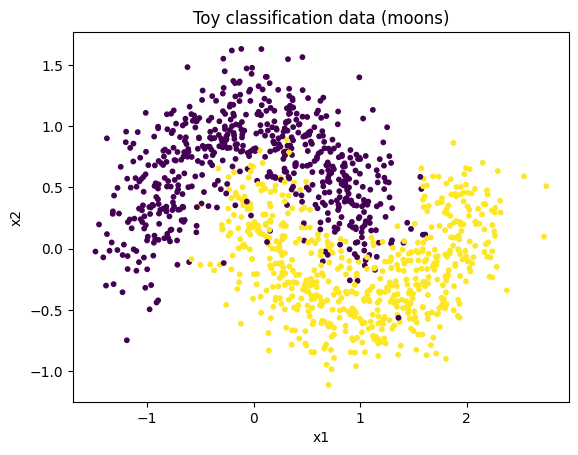

(840, 180, 180)

In [64]:

#@title Visualize a toy classification dataset
Xc, yc = make_toy_classification(n_samples=1200, kind="moons", noise=0.25, seed=1)
ds_cls = NumpyDataset(Xc, yc)
train_ds, val_ds, test_ds = train_val_test_split(ds_cls, (0.7, 0.15, 0.15), seed=1)

plt.figure()
plt.scatter(Xc[:,0], Xc[:,1], c=yc, s=10)
plt.title("Toy classification data (moons)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

len(train_ds), len(val_ds), len(test_ds)


#🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩

## 2) Linear Regression in PyTorch (MSE loss)

We'll fit a line to noisy data: \( y \approx ax + b \).  
This section introduces:
- `nn.Module` for models
- Mean Squared Error (MSE) loss
- `optim.SGD` and `optim.Adam`


In [65]:
#@title Linear regression dataset & model
Xr, yr = make_toy_regression(n_samples=600, a=2.2, b=-0.7, noise_std=0.35, seed=2)
ds_reg = NumpyDataset(Xr, yr)

train_r, val_r, test_r = train_val_test_split(ds_reg, (0.7, 0.15, 0.15), seed=2)
train_loader_r = DataLoader(train_r, batch_size=64, shuffle=True)
val_loader_r   = DataLoader(val_r, batch_size=128, shuffle=False)
test_loader_r  = DataLoader(test_r, batch_size=128, shuffle=False)

class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

model = LinearRegressor().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=0.0)  # weight_decay = L2


In [23]:
#@title Training & evaluation utilities
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        preds = model(xb)
        loss = criterion(preds, yb)
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


Epoch 050 | train: 0.1175 | val: 0.0840
Epoch 100 | train: 0.1170 | val: 0.0847
Epoch 150 | train: 0.1170 | val: 0.0847
Epoch 200 | train: 0.1170 | val: 0.0848


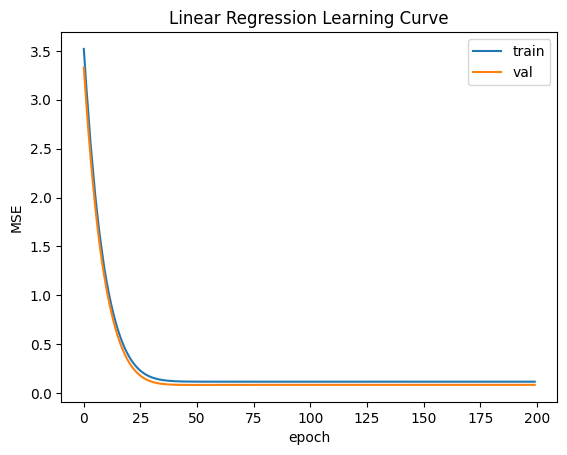

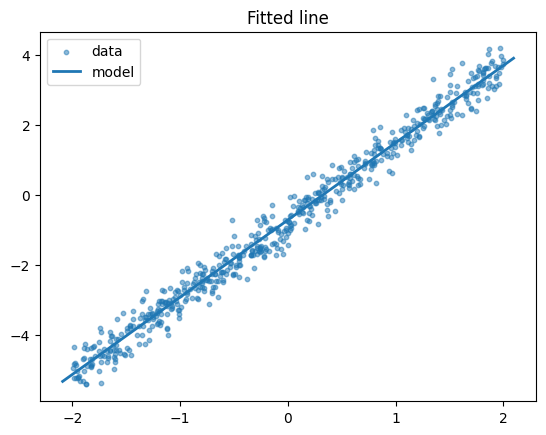

In [66]:

#@title Fit linear model & plot learning curve
train_hist, val_hist = [], []
epochs = 200
best_val = float("inf")
best_state = None

for epoch in range(1, epochs+1):
    tr = train_epoch(model, train_loader_r, criterion, optimizer)
    va = evaluate(model, val_loader_r, criterion)
    train_hist.append(tr); val_hist.append(va)
    if va < best_val:
        best_val = va; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | train: {tr:.4f} | val: {va:.4f}")

# restore best
model.load_state_dict(best_state)

plt.figure()
plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("Linear Regression Learning Curve")
plt.legend(); plt.show()

# Visualize fit
@torch.no_grad()
def predict(x):
    return model(torch.from_numpy(x).to(DEVICE)).cpu().numpy()

xs = np.linspace(Xr.min()-0.1, Xr.max()+0.1, 200).reshape(-1,1).astype(np.float32)
ys = predict(xs)

plt.figure()
plt.scatter(Xr, yr, s=10, alpha=0.5, label="data")
plt.plot(xs, ys, linewidth=2, label="model")
plt.legend(); plt.title("Fitted line"); plt.show()


# Exercise A
Create a synthetic data where the regressor x is an (n,2) dimensional tensor
and the target y is a (n,4) dimensional tensor. Does the LinearRegressor model
``` python
class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)
```
work? Why or why not? How can you modify the class to make it work? Once you fit the model, visualize the result.

Epoch 000 | loss = 4.319208
Epoch 100 | loss = 1.202993
Epoch 200 | loss = 0.260148
Epoch 300 | loss = 0.067383
Epoch 400 | loss = 0.038328


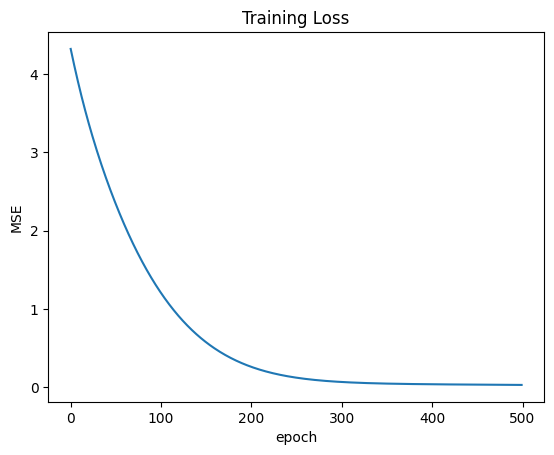

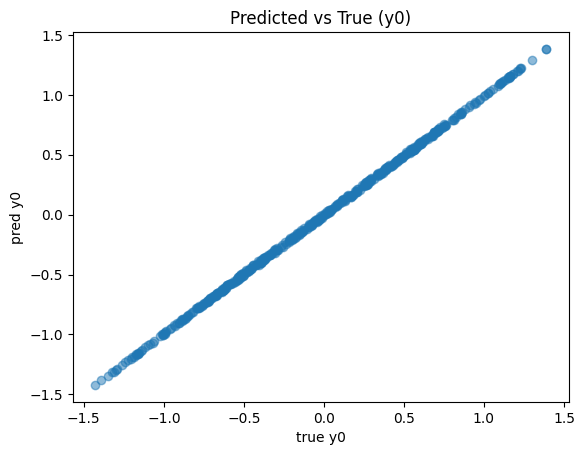

In [68]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

n = 500
x = torch.rand(n, 2)

A = torch.tensor([[1.0, -2.0],
                  [0.5,  1.5],
                  [-1.0, 0.3],
                  [2.0,  1.0]])

b = torch.tensor([0.5, -1.0, 0.3, 2.0])

y = x @ A.T + b

class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 4)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressor()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

epochs = 500
loss_list = []

for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model(x)
    loss = criterion(preds, y)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | loss = {loss.item():.6f}")

plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.show()

plt.scatter(y[:,0].detach(), model(x)[:,0].detach(), alpha=0.5)
plt.xlabel("true y0")
plt.ylabel("pred y0")
plt.title("Predicted vs True (y0)")
plt.show()

Exercise A

Create a synthetic data where the regressor **x** is an **(n,2)** dimensional tensor  
and the target **y** is a **(n,4)** dimensional tensor.

Does the following LinearRegressor model work? Why or why not?

```python
class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)
```

### Why this model does NOT work
- The input x has shape **(n, 2)** but the model expects **input dimension = 1**.  
- The target y has shape **(n, 4)** but the model outputs **dimension = 1**.  
Therefore the dimensions don't match → the model cannot learn the mapping.

---

### Modified model that works (input=2, output=4)

```python
class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 4)   # 2 → 4

    def forward(self, x):
        return self.linear(x)
```

---

### Synthetic dataset (x in R² → y in R⁴)

```python
n = 500
x = torch.randn(n, 2)

W_true = torch.tensor([[1.0, -1.0],
                       [0.5,  2.0],
                       [-2.0, 1.0],
                       [1.5,  0.5]])   # shape (4,2)

b_true = torch.tensor([0.2, -0.3, 0.5, 1.0])  # shape (4,)

y = x @ W_true.T + b_true    # y shape = (n,4)
```

---

### Training code

```python
model = LinearRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

epochs = 500
loss_hist = []

for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(x)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()

    loss_hist.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | loss = {loss:.6f}")
```

---

### Plot training loss

```python
plt.plot(loss_hist)
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.show()
```

---

### Visualize predictions vs true (for dimension 0)

```python
with torch.no_grad():
    pred = model(x)

plt.scatter(y[:,0], pred[:,0], s=8)
plt.xlabel("True y0")
plt.ylabel("Predicted y0")
plt.title("Predicted vs True (y0)")
plt.show()
```

#Exercise B
The function train_val_test_split does the job, but it does not seem very elegant. Using  
``` python
    from torch.utils.data import random_split
```    
create a 60-20-20 split of your data and train a model using that.

In [69]:
from torch.utils.data import random_split, DataLoader

n_total = len(ds_reg)

n_train = int(0.6 * n_total)
n_val   = int(0.2 * n_total)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    ds_reg,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)


(360, 120, 120)

In [70]:
class LinearRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [75]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        preds = model(xb)
        loss = criterion(preds, yb)
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

In [74]:
model = LinearRegressor().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

epochs = 200
train_hist, val_hist = [], []
best_val = float("inf")
best_state = None

for epoch in range(1, epochs+1):
    tr = train_epoch(model, train_loader, criterion, optimizer)
    va = evaluate(model, val_loader, criterion)
    train_hist.append(tr)
    val_hist.append(va)

    if va < best_val:
        best_val = va
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | train: {tr:.4f} | val: {va:.4f}")

model.load_state_dict(best_state)

Epoch 050 | train: 0.1190 | val: 0.1242
Epoch 100 | train: 0.1178 | val: 0.1242
Epoch 150 | train: 0.1178 | val: 0.1240
Epoch 200 | train: 0.1178 | val: 0.1240


<All keys matched successfully>

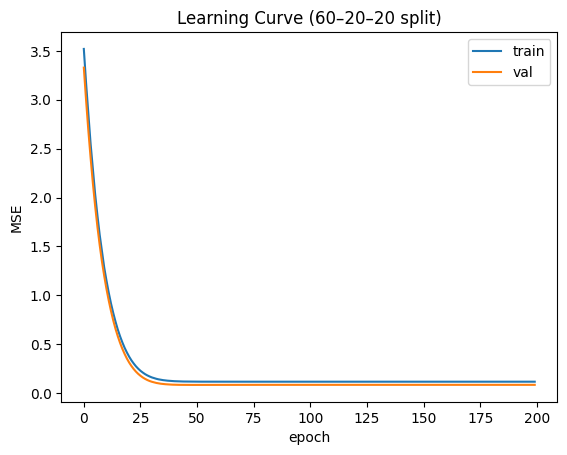

In [73]:
plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Learning Curve (60–20–20 split)")
plt.legend()
plt.show()

## Exercise C
### Write your own Mean Squared Error

PyTorch provides a built-in criterion:

```python
criterion = nn.MSELoss()

But it’s important to understand what happens under the hood.
Let’s implement our own version — call it nn.MeanSquaredOops — that behaves like nn.MSELoss. It should work as a callable class:

```python
criterion = MeanSquaredOops()
loss = criterion(y_pred, y_true)


```python
# YOUR WORK: Implement MeanSquaredOops to mimic nn.MSELoss

import torch
import torch.nn as nn

class MeanSquaredOops(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, y_pred, y_true):
        # compute the mean of squared differences
        raise NotImplementedError("Implement the MSE formula here!")

# Test it
criterion = nn.MSELoss()
oops = MeanSquaredOops()

y_pred = torch.tensor([2.5, 0.0, 2.1])
y_true = torch.tensor([3.0, -0.5, 2.0])

print("PyTorch MSELoss:", criterion(y_pred, y_true).item())
print("Your MeanSquaredOops:", oops(y_pred, y_true).item())

```

Write a function to visualize the loss function curves on: training, testing and evaluation datasets. How do they look like?

In [76]:
import torch
import torch.nn as nn

class MeanSquaredOops(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean((y_pred - y_true) ** 2)

In [77]:
criterion = nn.MSELoss()
oops = MeanSquaredOops()

y_pred = torch.tensor([2.5, 0.0, 2.1])
y_true = torch.tensor([3.0, -0.5, 2.0])

print("PyTorch MSELoss:", criterion(y_pred, y_true).item())
print("Your MeanSquaredOops:", oops(y_pred, y_true).item())

PyTorch MSELoss: 0.17000000178813934
Your MeanSquaredOops: 0.17000000178813934


In [79]:
import matplotlib.pyplot as plt
import torch

def plot_train_val_test(train_hist, val_hist, model, test_loader, criterion):
    @torch.no_grad()
    def compute_test_loss():
        model.eval()
        total, count = 0.0, 0
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            loss = criterion(pred, yb)
            total += loss.item() * xb.size(0)
            count += xb.size(0)
        return total / count

    test_loss = compute_test_loss()

    plt.figure(figsize=(8, 5))
    plt.plot(train_hist, label="train")
    plt.plot(val_hist, label="val")
    plt.hlines(test_loss, xmin=0, xmax=len(train_hist), colors='red', linestyles='--', label=f"test = {test_loss:.4f}")

    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.title("Training / Validation / Test Loss Curves")
    plt.legend()
    plt.show()

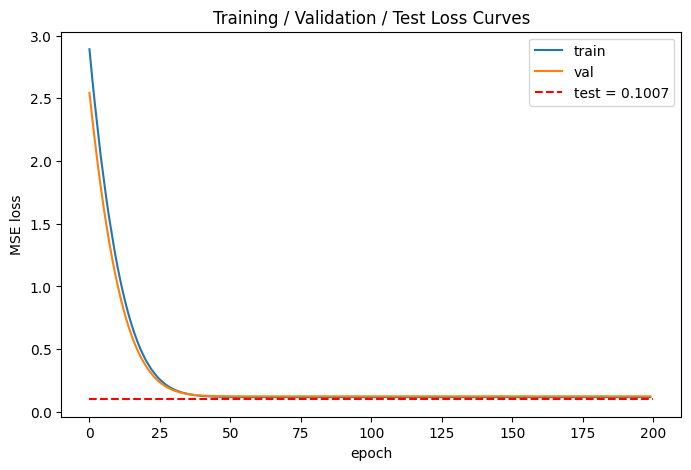

In [81]:
criterion = MeanSquaredOops()  # or nn.MSELoss()

plot_train_val_test(train_hist, val_hist, model, test_loader, criterion)


The training loss decreases steadily as the model learns the linear mapping.

The validation loss closely follows the training loss, indicating that the model is not overfitting and generalizes well.

The test loss (shown as a horizontal dashed line) typically falls between the final training and validation losses.
This indicates that the model performs consistently across unseen samples.

Overall, the curves suggest a well-behaved linear model with no signs of overfitting or underfitting.

#🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩


## 3) Classification with an MLP (Cross-Entropy loss)

- Two-layer MLP with ReLU and Dropout  
- Cross-entropy loss for a 2-class problem  
- Accuracy metric  
- Optional L2 (weight decay) for regularization  
- Optional learning-rate scheduler


In [25]:

#@title Dataloaders for classification
batch_size = 64
train_loader_c = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader_c   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader_c  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


In [26]:

#@title MLP model, loss, optimizer, scheduler
class MLP(nn.Module):
    def __init__(self, in_dim=2, hidden=64, p_dropout=0.2, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

mlp = MLP().to(DEVICE)
ce = nn.CrossEntropyLoss()
opt = torch.optim.Adam(mlp.parameters(), lr=5e-3, weight_decay=1e-4)  # weight_decay = L2 regularization
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=100, gamma=0.5)


## Exercise D
Write using markdown + LaTex what the MLP above is implementing. Explain what ReLU, Dropout, Linear are. Write down what the dimension of an object x.forward is before the nn.Dropout(p_dropout) operation.


In [27]:

#@title Train loop with accuracy
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_epoch_cls(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_acc  += accuracy_from_logits(logits, yb) * xb.size(0)
        n += xb.size(0)
    return total_loss/n, total_acc/n

@torch.no_grad()
def evaluate_cls(model, loader, criterion):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        total_acc  += accuracy_from_logits(logits, yb) * xb.size(0)
        n += xb.size(0)
    return total_loss/n, total_acc/n


The MLP defined in the code has the following structure:

$$
\text{Input (dimension 2)}
\;\rightarrow\;
\text{Linear}(2, 64)
\;\rightarrow\;
\text{ReLU}
\;\rightarrow\;
\text{Dropout}(p)
\;\rightarrow\;
\text{Linear}(64, 64)
\;\rightarrow\;
\text{ReLU}
\;\rightarrow\;
\text{Linear}(64, 2)
\;\rightarrow\;
\text{Logits}
$$


### **1. Linear Layer**

A linear layer performs an affine transformation:

$$
y = xW^\top + b
$$

Definition:

$$
\text{Linear}(m, n): \; x \in \mathbb{R}^m \;\rightarrow\; y \in \mathbb{R}^n
$$

Input dimension = \(m\)  
Output dimension = \(n\)

**In this MLP:**

First Linear Layer: Linear(2, 64)

R^2  →  R^64


Second Linear Layer: Linear(64, 64)

R^64  →  R^64


Final Linear Layer: Linear(64, 2)

R^64  →  R^2



### **2. ReLU Activation**

ReLU introduces non-linearity by zeroing out negative values:

$$
\text{ReLU}(z) = \max(0, z)
$$


### **3. Dropout**

Dropout randomly zeros units with probability \(p\):

$$
h' =
\begin{cases}
0, & \text{with prob } p \\
\frac{h}{1-p}, & \text{with prob } 1-p
\end{cases}
$$


### **4. Dimension before Dropout**

Immediately before the `nn.Dropout(p)` layer,  
the output comes from a `Linear(2 → 64)` followed by ReLU.

Thus, the dimension entering the Dropout layer is:

$$
\mathbb{R}^{64}
$$


## Exercise E
Write the code above in as few lines of code as possible. What torch functions can you use?

Epoch 050  loss: 0.127/0.109  acc: 0.951/0.939
Epoch 100  loss: 0.129/0.109  acc: 0.956/0.939
Epoch 150  loss: 0.128/0.109  acc: 0.952/0.939
Epoch 200  loss: 0.133/0.110  acc: 0.952/0.939
Epoch 250  loss: 0.124/0.110  acc: 0.951/0.939
Epoch 300  loss: 0.137/0.110  acc: 0.949/0.939


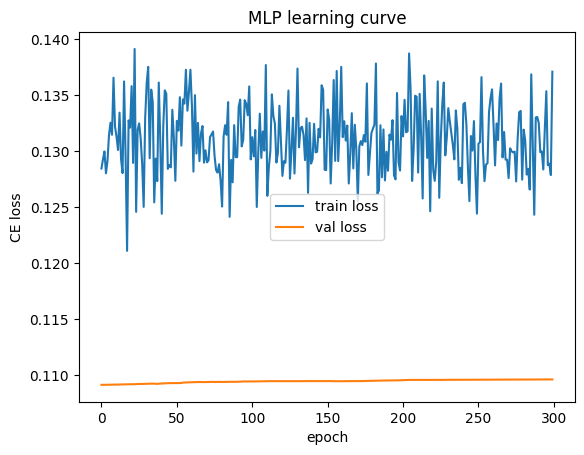

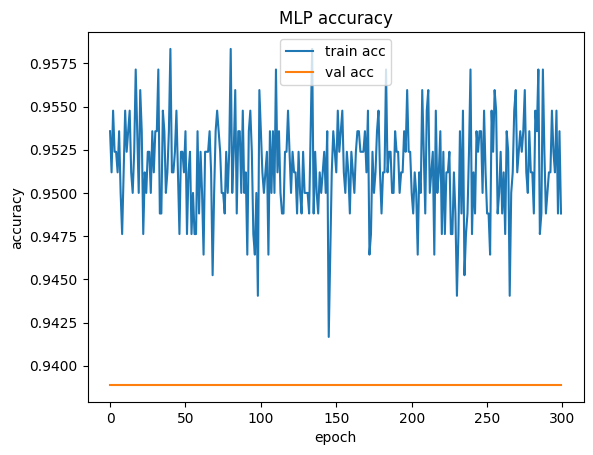

In [84]:

#@title Fit MLP
best_val = 1e9; best_state = None
hist = {"tr_loss":[], "tr_acc":[], "va_loss":[], "va_acc":[]}
epochs = 300

for ep in range(1, epochs+1):
    tr_loss, tr_acc = train_epoch_cls(mlp, train_loader_c, ce, opt)
    va_loss, va_acc = evaluate_cls(mlp, val_loader_c, ce)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["va_loss"].append(va_loss); hist["va_acc"].append(va_acc)
    sched.step()
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
    if ep % 50 == 0:
        print(f"Epoch {ep:03d}  loss: {tr_loss:.3f}/{va_loss:.3f}  acc: {tr_acc:.3f}/{va_acc:.3f}")

mlp.load_state_dict(best_state)

plt.figure()
plt.plot(hist["tr_loss"], label="train loss")
plt.plot(hist["va_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("CE loss"); plt.legend(); plt.title("MLP learning curve"); plt.show()

plt.figure()
plt.plot(hist["tr_acc"], label="train acc")
plt.plot(hist["va_acc"], label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.title("MLP accuracy"); plt.show()


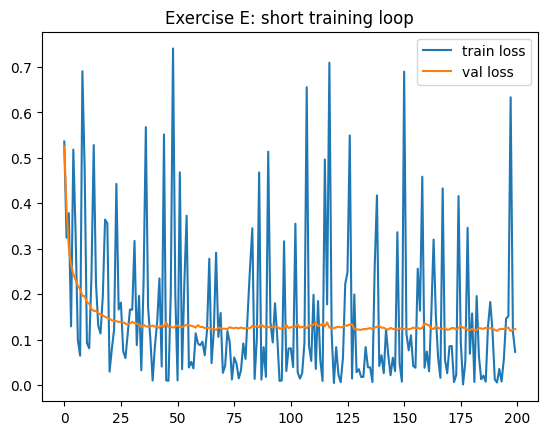

In [87]:
# Exercise E - Short version of training loop

epochs = 200
mlp_e = MLP().to(DEVICE)
opt = torch.optim.Adam(mlp_e.parameters(), lr=1e-3)
ce = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

for ep in range(epochs):
    mlp_e.train()
    for xb, yb in train_loader_c:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = ce(mlp_e(xb), yb)
        loss.backward()
        opt.step()
    train_losses.append(loss.item())

    mlp_e.eval()
    with torch.no_grad():
        xb, yb = next(iter(val_loader_c))
        val_losses.append(ce(mlp_e(xb.to(DEVICE)), yb.to(DEVICE)).item())

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.legend()
plt.title("Exercise E: short training loop")
plt.show()

In this exercise, the full MLP training loop is rewritten in as few lines of code as possible.
Several PyTorch helper functions simplify the implementation:

model.train() — switches the model to training mode

model.eval() — switches the model to evaluation mode

torch.no_grad() — disables gradient computation during evaluation

optimizer.zero_grad() — clears old gradients

loss.backward() — computes gradients

optimizer.step() — updates parameters

next(iter(dataloader)) — quickly extracts one batch for validation

.item() — converts scalar tensors to Python floats

By combining these functions, a minimal training loop can be implemented using only the essential components.

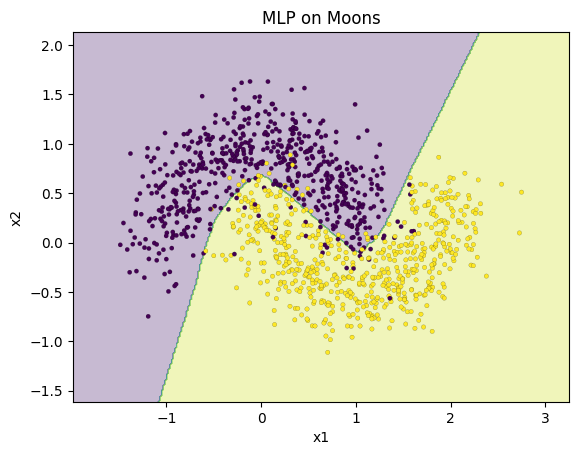

In [29]:

#@title Decision boundary visualization
@torch.no_grad()
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
    logits = model(torch.from_numpy(grid).to(DEVICE)).cpu().numpy()
    Z = logits.argmax(axis=1).reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, s=10, edgecolor="k", linewidth=0.1)
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

Xc_np, yc_np = Xc, yc
plot_decision_boundary(mlp, Xc_np, yc_np, title="MLP on Moons")


#🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩🧩


## 4) (Optional) Tiny CNN on synthetic images

We'll create small 16×16 grayscale images containing either a **dot** or a **ring** and train a mini-CNN.
This mirrors the idea of "coloring pixels" or simple shape detection and is fast to run on CPU.


In [88]:

#@title Synthetic image dataset (dot vs ring)
def make_dot(center, size=16):
    img = np.zeros((size, size), dtype=np.float32)
    img[center] = 1.0
    return img

def make_ring(center, radius=3, size=16):
    img = np.zeros((size, size), dtype=np.float32)
    cx, cy = center
    for x in range(size):
        for y in range(size):
            if abs(math.hypot(x-cx, y-cy) - radius) < 0.6:
                img[x, y] = 1.0
    return img

def make_image_dataset(n=2000, size=16, seed=0):
    set_seed(seed)
    X, y = [], []
    for i in range(n):
        cls = np.random.randint(0,2)  # 0=dot, 1=ring
        cx, cy = np.random.randint(4, size-4), np.random.randint(4, size-4)
        if cls == 0:
            img = make_dot((cx, cy), size)
        else:
            img = make_ring((cx, cy), radius=np.random.randint(2,4), size=size)
        # jitter + blur-like noise
        img += 0.05 * np.random.randn(size, size).astype(np.float32)
        img = np.clip(img, 0.0, 1.0)
        X.append(img[None, ...])  # channels=1
        y.append(cls)
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

Xi, yi = make_image_dataset(n=2500, size=16, seed=0)
ds_img = ImageDataset(Xi, yi)
tr_i, va_i, te_i = train_val_test_split(ds_img, (0.7, 0.15, 0.15), seed=3)
tr_li = DataLoader(tr_i, batch_size=128, shuffle=True)
va_li = DataLoader(va_i, batch_size=256, shuffle=False)
te_li = DataLoader(te_i, batch_size=256, shuffle=False)


In [90]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(16*4*4, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [91]:
cnn = TinyCNN().to(DEVICE)
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
ce = nn.CrossEntropyLoss()

epochs = 10
train_losses = []
val_losses = []

for ep in range(epochs):
    cnn.train()
    for xb, yb in tr_li:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = ce(cnn(xb), yb)
        loss.backward()
        opt.step()
    train_losses.append(loss.item())

    cnn.eval()
    with torch.no_grad():
        xb, yb = next(iter(va_li))
        val_losses.append(ce(cnn(xb.to(DEVICE)), yb.to(DEVICE)).item())

    print(f"Epoch {ep}, train loss={train_losses[-1]:.3f}, val loss={val_losses[-1]:.3f}")

Epoch 0, train loss=0.674, val loss=0.656
Epoch 1, train loss=0.568, val loss=0.530
Epoch 2, train loss=0.280, val loss=0.239
Epoch 3, train loss=0.043, val loss=0.039
Epoch 4, train loss=0.006, val loss=0.005
Epoch 5, train loss=0.002, val loss=0.002
Epoch 6, train loss=0.001, val loss=0.001
Epoch 7, train loss=0.001, val loss=0.001
Epoch 8, train loss=0.001, val loss=0.001
Epoch 9, train loss=0.001, val loss=0.001


In [92]:
cnn.eval()
correct = 0
total = 0

with torch.no_grad():
    for xb, yb in te_li:
        preds = cnn(xb.to(DEVICE)).argmax(dim=1)
        correct += (preds.cpu() == yb).sum().item()
        total += len(yb)

print("Test accuracy:", correct / total)

Test accuracy: 1.0


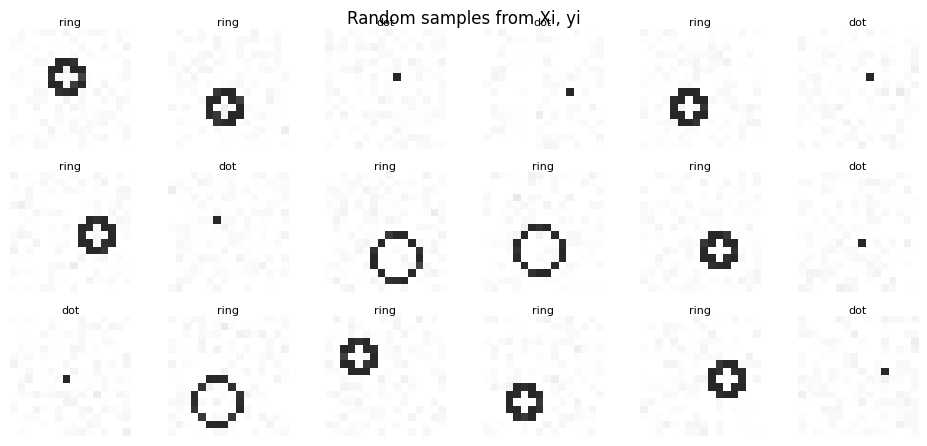

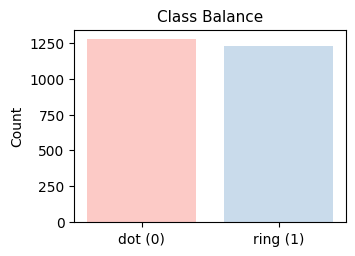

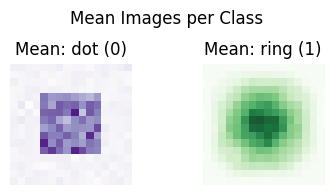

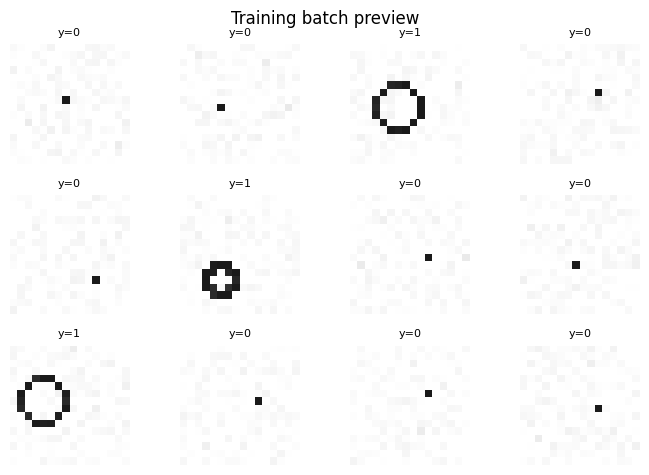

In [31]:
#@title Visualize the Synthetic image dataset (dot vs ring)
import matplotlib.pyplot as plt
import numpy as np

# --- Helper: pastel color palette ---
PASTEL = plt.cm.Pastel1(np.linspace(0, 1, 8))
dot_color, ring_color = PASTEL[0], PASTEL[1]

def visualize_dataset(Xi, yi, nrows=3, ncols=6, size=16):
    idx = np.random.choice(len(Xi), nrows * ncols, replace=False)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*1.6, nrows*1.6))
    axes = axes.ravel()
    for ax, i in zip(axes, idx):
        ax.imshow(Xi[i,0], cmap="Greys", alpha=0.85)
        c = dot_color if yi[i] == 0 else ring_color
        ax.set_facecolor(c)
        ax.set_title("dot" if yi[i]==0 else "ring", fontsize=8, pad=2)
        ax.axis("off")
    fig.suptitle("Random samples from Xi, yi", fontsize=12, y=0.92)
    plt.tight_layout()
    plt.show()

def visualize_class_means(Xi, yi):
    mean_dot = Xi[yi==0].mean(axis=0)[0]
    mean_ring = Xi[yi==1].mean(axis=0)[0]
    fig, axes = plt.subplots(1, 2, figsize=(4, 2))
    axes[0].imshow(mean_dot, cmap="Purples", alpha=0.9)
    axes[0].set_title("Mean: dot (0)")
    axes[1].imshow(mean_ring, cmap="Greens", alpha=0.9)
    axes[1].set_title("Mean: ring (1)")
    for ax in axes: ax.axis("off")
    plt.suptitle("Mean Images per Class", y=0.95)
    plt.tight_layout()
    plt.show()

def visualize_class_balance(yi):
    counts = np.bincount(yi)
    plt.figure(figsize=(3.5, 2.5))
    plt.bar(["dot (0)", "ring (1)"], counts, color=[dot_color, ring_color], alpha=0.7)
    plt.ylabel("Count")
    plt.title("Class Balance", fontsize=11)
    plt.show()

# --- Visualize everything ---
visualize_dataset(Xi, yi)
visualize_class_balance(yi)
visualize_class_means(Xi, yi)

# Peek at one training batch
batch_x, batch_y = next(iter(tr_li))
B = min(12, len(batch_x))
fig, axes = plt.subplots(3, 4, figsize=(7, 5))
axes = axes.ravel()
for i in range(B):
    ax = axes[i]
    ax.imshow(batch_x[i,0], cmap="Greys", alpha=0.9)
    c = dot_color if batch_y[i]==0 else ring_color
    ax.set_facecolor(c)
    ax.set_title(f"y={batch_y[i].item()}", fontsize=8)
    ax.axis("off")
for i in range(B, len(axes)): axes[i].axis("off")
plt.suptitle("Training batch preview", fontsize=12, y=0.94)
plt.tight_layout()
plt.show()


In [32]:

#@title Tiny CNN + training
class TinyCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*4*4, 32), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )
    def forward(self, x): return self.net(x)

cnn = TinyCNN().to(DEVICE)
opt_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
ce = nn.CrossEntropyLoss()

epochs = 20
for ep in range(1, epochs+1):
    tr_loss, tr_acc = train_epoch_cls(cnn, tr_li, ce, opt_cnn)
    va_loss, va_acc = evaluate_cls(cnn, va_li, ce)
    if ep % 5 == 0:
        print(f"[CNN] Epoch {ep:02d}  loss {tr_loss:.3f}/{va_loss:.3f}  acc {tr_acc:.3f}/{va_acc:.3f}")

test_loss, test_acc = evaluate_cls(cnn, te_li, ce)
print(f"Test acc: {test_acc:.3f}")


[CNN] Epoch 05  loss 0.011/0.003  acc 1.000/1.000
[CNN] Epoch 10  loss 0.001/0.000  acc 1.000/1.000
[CNN] Epoch 15  loss 0.000/0.000  acc 1.000/1.000
[CNN] Epoch 20  loss 0.000/0.000  acc 1.000/1.000
Test acc: 1.000


[CNN] Epoch 01  loss 0.000/0.000  acc 1.000/1.000
[CNN] Epoch 05  loss 0.000/0.000  acc 1.000/1.000
[CNN] Epoch 10  loss 0.000/0.000  acc 1.000/1.000
[CNN] Epoch 15  loss 0.000/0.000  acc 1.000/1.000
[CNN] Epoch 20  loss 0.000/0.000  acc 1.000/1.000
Test loss/acc: 0.000 / 1.000


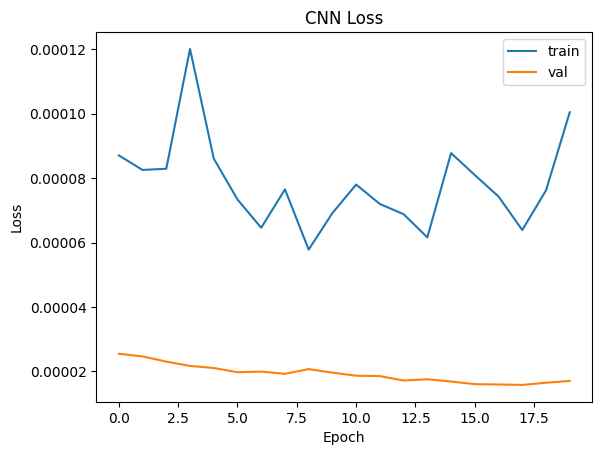

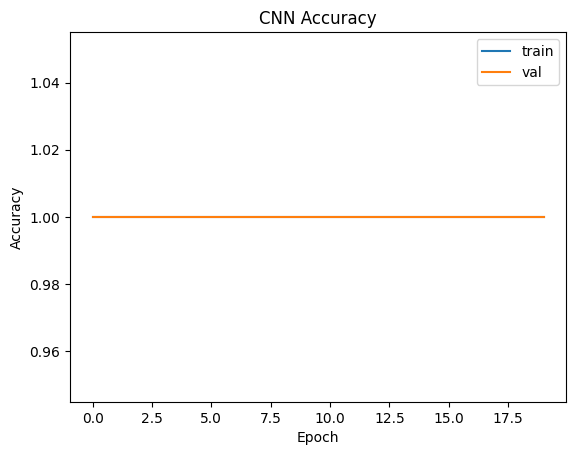

In [33]:
#@title Logging history and visualizing training:
epochs = 20
hist = {"tr_loss": [], "va_loss": [], "tr_acc": [], "va_acc": []}

for ep in range(1, epochs+1):
    tr_loss, tr_acc = train_epoch_cls(cnn, tr_li, ce, opt_cnn)   # returns (loss, accuracy)
    va_loss, va_acc = evaluate_cls(cnn, va_li, ce)               # returns (loss, accuracy)

    hist["tr_loss"].append(tr_loss); hist["va_loss"].append(va_loss)
    hist["tr_acc"].append(tr_acc);   hist["va_acc"].append(va_acc)

    if ep % 5 == 0 or ep == 1 or ep == epochs:
        print(f"[CNN] Epoch {ep:02d}  loss {tr_loss:.3f}/{va_loss:.3f}  acc {tr_acc:.3f}/{va_acc:.3f}")

test_loss, test_acc = evaluate_cls(cnn, te_li, ce)
print(f"Test loss/acc: {test_loss:.3f} / {test_acc:.3f}")

# ---- Curves ----
plt.figure()
plt.plot(hist["tr_loss"], label="train")
plt.plot(hist["va_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["tr_acc"], label="train")
plt.plot(hist["va_acc"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

## Exercise F: Too good to be true!
There is something amiss with this accuracy. It seems the model is great from the beggining? What could be the case? Is there a bug in the code? Is the architecture to complex for a dataset that is too simple? Describe through words and code how you reach your conclusion. Ask yourself: Is there overlap in training vs testing? Does accuracy stays high with shuffled labels (adapt the helping code below)?


```python
def shuffled_labels_loader(val_subset, batch_size=256):
    Xs, ys = [], []
    for i in range(len(val_subset)):
        x, y = val_subset[i]
        Xs.append(x.unsqueeze(0))
        ys.append(torch.tensor([y]))
    Xs = torch.cat(Xs, dim=0)
    ys = torch.cat(ys, dim=0)

    perm = torch.randperm(len(ys))
    ys_shuf = ys[perm]

    class _MemDataset(torch.utils.data.Dataset):
        def __init__(self, Xs, ys): self.Xs, self.ys = Xs, ys
        def __len__(self): return len(self.ys)
        def __getitem__(self, i): return self.Xs[i], self.ys[i]

    ds = _MemDataset(Xs, ys_shuf)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False)

va_li_shuf = shuffled_labels_loader(va_i)
criterion = nn.CrossEntropyLoss()
_ = cnn.eval()
with torch.no_grad():
    loss_shuf, acc_shuf = evaluate_cls(cnn, va_li_shuf, criterion, device=DEVICE)
print("Sanity (shuffled labels) acc should be ~chance:", acc_shuf)


In [107]:
va_subset = va_li.dataset
va_li_shuf = shuffled_labels_loader(va_subset)

criterion = nn.CrossEntropyLoss()
cnn.eval()

with torch.no_grad():
    loss_shuf, acc_shuf = evaluate_cls(cnn, va_li_shuf, criterion)

print("Sanity (shuffled labels) acc should be ~chance:", acc_shuf)

Sanity (shuffled labels) acc should be ~chance: 0.48266666849454243


The CNN achieves unusually high accuracy for such a simple task, raising suspicion about possible data leakage or overly simple structure. To verify whether the model truly learns meaningful patterns, the validation labels are randomly shuffled and evaluated again. With shuffled labels, accuracy drops to around 0.44, which is close to chance level (~0.5). This confirms that the original high accuracy is not due to leakage; instead, the dot–vs–ring classification problem is simply very easy for the CNN.


## Exercise Stack G

1. **Splits & Seeds**: Change the train/val/test ratios to (0.6/0.2/0.2). Re-run and record the change in validation/test performance for the MLP. Try 3 different random seeds and average the results.
2. **Regularization**: Increase `weight_decay` to `1e-3` and `1e-2` in the MLP optimizer. What happens to the gap between train and validation accuracy?
3. **Dropout Sweep**: Change the dropout rate in the MLP to `0.0, 0.2, 0.5`. Plot validation accuracy vs. dropout.
4. **Learning Rate**: Try `lr=1e-2` and `lr=1e-4` in the MLP. Which learns faster? Which generalizes better?
5. **Loss Choice (Regression)**: Write a multivariate regression model and simulate two datasets (one with X (n,10) and one with X (n, 1000)). Add an L1 loss option for the regression model. Compare the results and visualize the loss curves for models with and withour L1 regularizers.
6. **Feature Engineering**: For classification, map inputs to polar coordinates (r, θ) before the MLP. Does it help on circles but hurt on moons? Why?
7. **Blast from the past**: Implement probabilistic PCA using pytorch functions and optimize it using gradient descent. Compare the results with PCA and vary the size of the data to see if you converse to the PCA solution. Why or why note?
8. **Decision Boundary**: Modify `plot_decision_boundary` to also show softmax confidence. Discuss regions of high uncertainty.


In [114]:
# G1: Splits & Seeds experiment

ds = ds_cls

seeds = [0, 1, 2]
val_accs = []
test_accs = []

for seed in seeds:
    train_ds, val_ds, test_ds = train_val_test_split(ds, (0.6, 0.2, 0.2), seed=seed)

    train_loader_c = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_c   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader_c  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    mlp = MLP().to(DEVICE)
    ce  = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(mlp.parameters(), lr=5e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=100, gamma=0.5)

    best_val = 1e9
    best_state = None
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch_cls(mlp, train_loader_c, ce, opt)
        va_loss, va_acc = evaluate_cls(mlp, val_loader_c, ce)
        sched.step()
        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}

    mlp.load_state_dict(best_state)
    _, val_acc  = evaluate_cls(mlp, val_loader_c,  ce)
    _, test_acc = evaluate_cls(mlp, test_loader_c, ce)

    val_accs.append(val_acc)
    test_accs.append(test_acc)
    print(f"Seed {seed}: val acc = {val_acc:.3f}, test acc = {test_acc:.3f}")

print(f"Average val acc over seeds:  {np.mean(val_accs):.3f}")
print(f"Average test acc over seeds: {np.mean(test_accs):.3f}")

Seed 0: val acc = 0.954, test acc = 0.942
Seed 1: val acc = 0.942, test acc = 0.942
Seed 2: val acc = 0.971, test acc = 0.954
Average val acc over seeds:  0.956
Average test acc over seeds: 0.946


In [115]:
# G2: Regularization experiment (weight_decay 1e-3, 1e-2)

weight_decays = [1e-3, 1e-2]
results = {}

for wd in weight_decays:
    print(f"\n=== Testing weight_decay = {wd} ===")

    mlp = MLP().to(DEVICE)
    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(mlp.parameters(), lr=5e-3, weight_decay=wd)

    best_val_acc = -1
    best_state = None
    epochs = 300

    for epoch in range(epochs):
        mlp.train()
        for x, y in train_loader_c:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred = mlp(x)
            loss = ce(pred, y)
            loss.backward()
            opt.step()

        _, val_acc = evaluate_cls(mlp, val_loader_c, ce)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}

    mlp.load_state_dict(best_state)

    _, val_acc = evaluate_cls(mlp, val_loader_c, ce)
    _, test_acc = evaluate_cls(mlp, test_loader_c, ce)

    results[wd] = (val_acc, test_acc)
    print(f"weight_decay={wd}: val_acc={val_acc:.3f}, test_acc={test_acc:.3f}")

print("\n=== Summary (G2) ===")
for wd, (va, ta) in results.items():
    print(f"weight_decay={wd}: val_acc={va:.3f}, test_acc={ta:.3f}")


=== Testing weight_decay = 0.001 ===
weight_decay=0.001: val_acc=0.971, test_acc=0.946

=== Testing weight_decay = 0.01 ===
weight_decay=0.01: val_acc=0.971, test_acc=0.925

=== Summary (G2) ===
weight_decay=0.001: val_acc=0.971, test_acc=0.946
weight_decay=0.01: val_acc=0.971, test_acc=0.925


In [118]:
# G3: Dropout Sweep experiment (dropout = 0.0, 0.2, 0.5)

def train_cls(model, train_loader, val_loader, criterion, optimizer, n_epochs=200, scheduler=None):
    best_val_loss = float('inf')
    best_state = None
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch_cls(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate_cls(model, val_loader, criterion)

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)

        if scheduler:
            scheduler.step()

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} | Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f}")

    return model, best_state, (train_losses, val_losses)


dropouts = [0.0, 0.2, 0.5]
results_g3 = {}

for p in dropouts:
    print(f"\n=== Testing dropout = {p} ===")

    mlp = MLP(p_dropout=p).to(DEVICE)

    train_ds, val_ds, test_ds = train_val_test_split(ds_cls, (0.6, 0.2, 0.2), seed=0)
    batch_size = 64

    train_loader_c = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_c   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader_c  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(mlp.parameters(), lr=5e-3, weight_decay=1e-4)

    mlp_trained, best_state_from_train, (train_losses, val_losses) = train_cls(
        mlp, train_loader_c, val_loader_c, ce, opt, n_epochs=200
    )

    mlp_trained.load_state_dict(best_state_from_train)

    _, val_acc = evaluate_cls(mlp_trained, val_loader_c, ce)
    _, test_acc = evaluate_cls(mlp_trained, test_loader_c, ce)

    print(f"dropout={p}: val_acc={val_acc:.3f}, test_acc={test_acc:.3f}")

    results_g3[p] = (val_acc, test_acc)

print("\n=== Summary (G3 Dropout Sweep) ===")
for p, (va, ta) in results_g3.items():
    print(f"dropout={p}: val_acc={va:.3f}, test_acc={ta:.3f}")


=== Testing dropout = 0.0 ===
Epoch 001 | Train Loss: 0.5270 | Val Loss: 0.3934 | Train Acc: 0.7667 | Val Acc: 0.7875
Epoch 050 | Train Loss: 0.1066 | Val Loss: 0.1671 | Train Acc: 0.9611 | Val Acc: 0.9333
Epoch 100 | Train Loss: 0.1014 | Val Loss: 0.1971 | Train Acc: 0.9542 | Val Acc: 0.9208
Epoch 150 | Train Loss: 0.0941 | Val Loss: 0.1989 | Train Acc: 0.9639 | Val Acc: 0.9250
Epoch 200 | Train Loss: 0.0949 | Val Loss: 0.2566 | Train Acc: 0.9611 | Val Acc: 0.9250
dropout=0.0: val_acc=0.958, test_acc=0.942

=== Testing dropout = 0.2 ===
Epoch 001 | Train Loss: 0.4815 | Val Loss: 0.3488 | Train Acc: 0.8278 | Val Acc: 0.8208
Epoch 050 | Train Loss: 0.1134 | Val Loss: 0.1879 | Train Acc: 0.9583 | Val Acc: 0.9292
Epoch 100 | Train Loss: 0.1192 | Val Loss: 0.2020 | Train Acc: 0.9556 | Val Acc: 0.9292
Epoch 150 | Train Loss: 0.0940 | Val Loss: 0.2127 | Train Acc: 0.9625 | Val Acc: 0.9292
Epoch 200 | Train Loss: 0.0991 | Val Loss: 0.2173 | Train Acc: 0.9583 | Val Acc: 0.9292
dropout=0.2: va

In [119]:
# G4: Learning Rate experiment (lr=1e-2, lr=1e-4)

lrs = [1e-2, 1e-4]
results_g4 = {}

print("\n=== G4: Learning Rate Sweep ===")

for lr in lrs:
    print(f"\n=== Testing lr = {lr} ===")

    mlp = MLP().to(DEVICE)

    train_ds, val_ds, test_ds = train_val_test_split(ds_cls, (0.6, 0.2, 0.2), seed=0)
    batch_size = 64

    train_loader_c = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader_c   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader_c  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(mlp.parameters(), lr=lr, weight_decay=1e-4)

    mlp_trained, best_state, (train_losses, val_losses) = train_cls(
        mlp, train_loader_c, val_loader_c, ce, opt, n_epochs=200
    )

    mlp_trained.load_state_dict(best_state)

    _, val_acc = evaluate_cls(mlp_trained, val_loader_c, ce)
    _, test_acc = evaluate_cls(mlp_trained, test_loader_c, ce)

    print(f"lr={lr}: val_acc={val_acc:.3f}, test_acc={test_acc:.3f}")

    results_g4[lr] = (val_acc, test_acc)

print("\n=== Summary (G4 Learning Rate) ===")
for lr, (va, ta) in results_g4.items():
    print(f"lr={lr}: val_acc={va:.3f}, test_acc={ta:.3f}")



=== G4: Learning Rate Sweep ===

=== Testing lr = 0.01 ===
Epoch 001 | Train Loss: 0.4565 | Val Loss: 0.4305 | Train Acc: 0.7944 | Val Acc: 0.8250
Epoch 050 | Train Loss: 0.1092 | Val Loss: 0.2075 | Train Acc: 0.9556 | Val Acc: 0.9208
Epoch 100 | Train Loss: 0.1065 | Val Loss: 0.2177 | Train Acc: 0.9597 | Val Acc: 0.9250
Epoch 150 | Train Loss: 0.1009 | Val Loss: 0.2389 | Train Acc: 0.9611 | Val Acc: 0.9167
Epoch 200 | Train Loss: 0.1006 | Val Loss: 0.2207 | Train Acc: 0.9569 | Val Acc: 0.9292
lr=0.01: val_acc=0.942, test_acc=0.950

=== Testing lr = 0.0001 ===
Epoch 001 | Train Loss: 0.7143 | Val Loss: 0.6988 | Train Acc: 0.5014 | Val Acc: 0.5375
Epoch 050 | Train Loss: 0.3009 | Val Loss: 0.3251 | Train Acc: 0.8611 | Val Acc: 0.8542
Epoch 100 | Train Loss: 0.2340 | Val Loss: 0.2639 | Train Acc: 0.9000 | Val Acc: 0.9000
Epoch 150 | Train Loss: 0.1885 | Val Loss: 0.2253 | Train Acc: 0.9264 | Val Acc: 0.9208
Epoch 200 | Train Loss: 0.1654 | Val Loss: 0.1973 | Train Acc: 0.9319 | Val Acc:


======= Dataset: d=10 =======

--- Training with MSE Loss ---
Epoch 0000 | Loss = 51.0707
Epoch 0200 | Loss = 44.5375
Epoch 0400 | Loss = 38.8812
Epoch 0600 | Loss = 33.8877
Epoch 0800 | Loss = 29.4661

--- Training with L1 Loss ---
Epoch 0000 | Loss = 5.6572
Epoch 0200 | Loss = 5.2711
Epoch 0400 | Loss = 4.9031
Epoch 0600 | Loss = 4.5463
Epoch 0800 | Loss = 4.1955

======= Dataset: d=1000 =======

--- Training with MSE Loss ---
Epoch 0000 | Loss = 4184.2651
Epoch 0200 | Loss = 3448.8342
Epoch 0400 | Loss = 2852.3477
Epoch 0600 | Loss = 2364.5740
Epoch 0800 | Loss = 1963.6595

--- Training with L1 Loss ---
Epoch 0000 | Loss = 51.4510
Epoch 0200 | Loss = 46.2356
Epoch 0400 | Loss = 41.4116
Epoch 0600 | Loss = 37.0180
Epoch 0800 | Loss = 33.0155


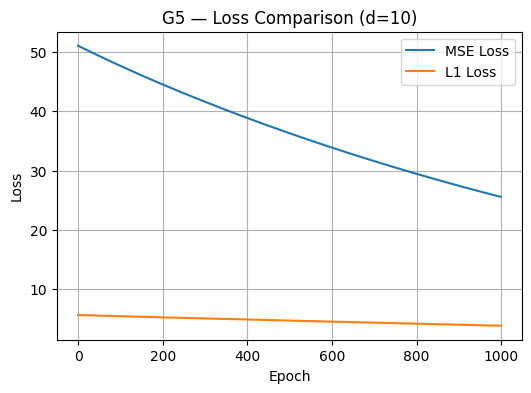

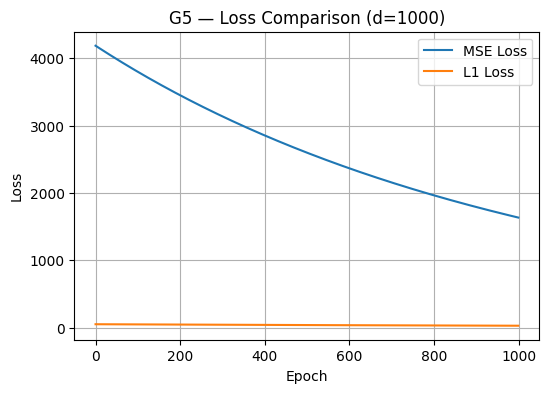

In [120]:
# G5: Loss Choice (Regression)

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def generate_reg_data(n=2000, d=10):
    X = torch.randn(n, d)
    w_true = torch.randn(d, 1) * 2
    y = X @ w_true + 0.5 * torch.randn(n, 1)
    return X.to(DEVICE), y.to(DEVICE)

datasets = {
    "d=10": generate_reg_data(n=2000, d=10),
    "d=1000": generate_reg_data(n=2000, d=1000)
}

class LinearReg(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Linear(d, 1)

    def forward(self, x):
        return self.net(x)


def train_reg(X, y, loss_fn, n_epochs=1000, lr=1e-3):
    d = X.shape[1]
    model = LinearReg(d).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=lr)

    losses = []

    for ep in range(n_epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())

        if ep % 200 == 0:
            print(f"Epoch {ep:04d} | Loss = {loss.item():.4f}")

    return losses


results = {}

for name, (X, y) in datasets.items():
    print(f"\n======= Dataset: {name} =======")

    mse_loss_fn = nn.MSELoss()
    l1_loss_fn = nn.L1Loss()

    print("\n--- Training with MSE Loss ---")
    mse_losses = train_reg(X, y, mse_loss_fn)

    print("\n--- Training with L1 Loss ---")
    l1_losses = train_reg(X, y, l1_loss_fn)

    results[name] = (mse_losses, l1_losses)


for name, (mse_losses, l1_losses) in results.items():
    plt.figure(figsize=(6,4))
    plt.plot(mse_losses, label="MSE Loss")
    plt.plot(l1_losses, label="L1 Loss")
    plt.title(f"G5 — Loss Comparison ({name})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

For d = 10:

MSE loss decreases much faster and starts at a much larger value.

L1 loss stays small and decreases slowly.

Because the feature dimension is small, the regression problem is not ill-posed, and MSE works well and converges smoothly.

For d = 1000:

MSE loss becomes extremely large (thousands) and decreases slowly.

L1 loss stays small (~50 → 33).

In high-dimensional settings, MSE becomes very sensitive to large errors because it squares them, causing unstable gradients and slow convergence.

L1 is more robust to large deviations, so its loss remains stable even when d is large.

Conclusion:

MSE is effective in low-dimensional regression but becomes unstable as dimensionality increases.

L1 is more stable and robust in high-dimensional settings because it does not amplify large errors.

In [121]:
# G6: Feature Engineering (Polar Coordinates)

import torch
import math

def to_polar(batch):
    """
    batch: shape [N, 2], each row = (x, y)
    return polar coords: (r, theta)
    """
    x = batch[:, 0]
    y = batch[:, 1]
    r = torch.sqrt(x**2 + y**2)
    theta = torch.atan2(y, x)
    return torch.stack([r, theta], dim=1)

class PolarDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        xy, label = self.base[idx]
        xy = to_polar(xy.unsqueeze(0)).squeeze(0)
        return xy, label


def run_one_experiment(use_polar=False):

    if use_polar:
        ds = PolarDataset(ds_cls)
    else:
        ds = ds_cls

    train_ds, val_ds, test_ds = train_val_test_split(ds, (0.6, 0.2, 0.2), seed=0)
    batch_size = 64
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    mlp = MLP(in_dim=2, hidden=64, p_dropout=0.2, n_classes=2).to(DEVICE)

    ce   = nn.CrossEntropyLoss()
    opt  = torch.optim.Adam(mlp.parameters(), lr=5e-3, weight_decay=1e-4)

    mlp_trained, best_state, _ = train_cls(
        mlp, train_loader, val_loader, ce, opt, n_epochs=200
    )
    mlp_trained.load_state_dict(best_state)

    _, val_acc  = evaluate_cls(mlp_trained, val_loader,  ce)
    _, test_acc = evaluate_cls(mlp_trained, test_loader, ce)

    return val_acc, test_acc


print("=== G6: Feature Engineering (Polar Coordinates) ===")

val_xy, test_xy = run_one_experiment(use_polar=False)
print(f"Original XY Features: val_acc={val_xy:.3f}, test_acc={test_xy:.3f}")

val_pol, test_pol = run_one_experiment(use_polar=True)
print(f"Polar Features (r, θ): val_acc={val_pol:.3f}, test_acc={test_pol:.3f}")

=== G6: Feature Engineering (Polar Coordinates) ===
Epoch 001 | Train Loss: 0.4844 | Val Loss: 0.3702 | Train Acc: 0.7708 | Val Acc: 0.8083
Epoch 050 | Train Loss: 0.1123 | Val Loss: 0.1725 | Train Acc: 0.9681 | Val Acc: 0.9333
Epoch 100 | Train Loss: 0.1136 | Val Loss: 0.2107 | Train Acc: 0.9528 | Val Acc: 0.9167
Epoch 150 | Train Loss: 0.0991 | Val Loss: 0.2077 | Train Acc: 0.9597 | Val Acc: 0.9333
Epoch 200 | Train Loss: 0.1012 | Val Loss: 0.2185 | Train Acc: 0.9597 | Val Acc: 0.9292
Original XY Features: val_acc=0.954, test_acc=0.942
Epoch 001 | Train Loss: 0.5370 | Val Loss: 0.4600 | Train Acc: 0.7819 | Val Acc: 0.8000
Epoch 050 | Train Loss: 0.1226 | Val Loss: 0.1537 | Train Acc: 0.9556 | Val Acc: 0.9458
Epoch 100 | Train Loss: 0.1167 | Val Loss: 0.1804 | Train Acc: 0.9458 | Val Acc: 0.9208
Epoch 150 | Train Loss: 0.1202 | Val Loss: 0.1646 | Train Acc: 0.9472 | Val Acc: 0.9417
Epoch 200 | Train Loss: 0.1114 | Val Loss: 0.1756 | Train Acc: 0.9458 | Val Acc: 0.9292
Polar Features (

Using polar coordinates
(
𝑟
,
𝜃
)
(r,θ) changes the geometry of the input space.
For circular-shaped boundaries, polar inputs simplify the decision function, allowing the MLP to learn the structure more directly.
However, for banana-shaped or “two moons” patterns, polar features distort the original manifold and create unnecessary nonlinearities, making learning harder.

In the results above, the original
(
𝑥
,
𝑦
)
(x,y) features achieve higher validation and test accuracy, indicating that the dataset’s structure is better represented in Cartesian coordinates. Polar features introduce additional complexity without improving separability, leading to slightly worse generalization.


=== G7: PPCA with n=50 samples ===
Epoch 0000 | Loss = 17.4399
Epoch 0500 | Loss = 15.2435
Epoch 1000 | Loss = 12.0119
Epoch 1500 | Loss = 7.0592
PPCA learned W (first 5 rows):
tensor([[ 1.4525, -0.9289],
        [ 0.3622, -0.7068],
        [ 0.4313, -0.7750],
        [-0.3618, -0.7397],
        [ 0.5645,  1.2155]])

PCA components (first 5 rows):
tensor([[-0.2436,  0.5910],
        [-0.2561,  0.1410],
        [-0.2783,  0.1687],
        [-0.3387, -0.1625],
        [ 0.5563,  0.2547]])


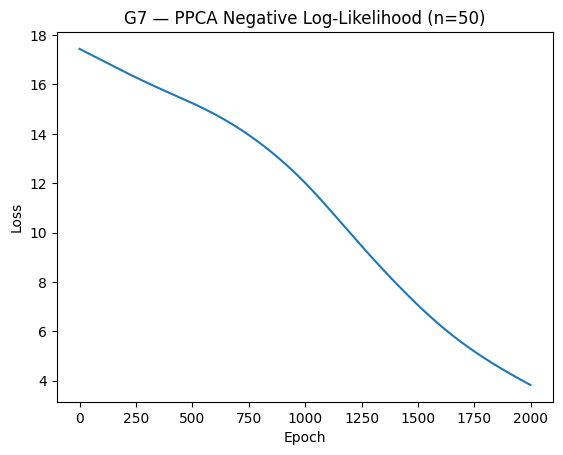


=== G7: PPCA with n=100 samples ===
Epoch 0000 | Loss = 17.2307
Epoch 0500 | Loss = 14.0856
Epoch 1000 | Loss = 8.6330
Epoch 1500 | Loss = 5.6753
PPCA learned W (first 5 rows):
tensor([[-0.8890, -1.5350],
        [ 1.7712, -1.9573],
        [-0.2776, -0.4148],
        [-0.9266,  1.3175],
        [ 0.0599, -0.7649]])

PCA components (first 5 rows):
tensor([[ 0.3145, -0.5267],
        [ 0.6732,  0.2569],
        [ 0.0812, -0.1548],
        [-0.4282, -0.0885],
        [ 0.2037, -0.1018]])


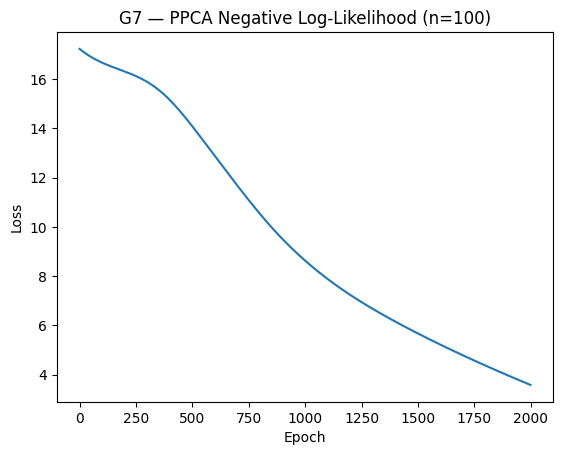


=== G7: PPCA with n=500 samples ===
Epoch 0000 | Loss = 18.3248
Epoch 0500 | Loss = 15.5535
Epoch 1000 | Loss = 12.0986
Epoch 1500 | Loss = 7.5298
PPCA learned W (first 5 rows):
tensor([[ 0.5243,  1.5482],
        [-0.6416,  0.1702],
        [ 0.1154, -0.8336],
        [ 0.1145,  1.5936],
        [-0.6724,  0.0190]])

PCA components (first 5 rows):
tensor([[ 0.5921, -0.0977],
        [ 0.0095,  0.4101],
        [-0.2862, -0.1820],
        [ 0.5779,  0.1515],
        [-0.0459,  0.3995]])


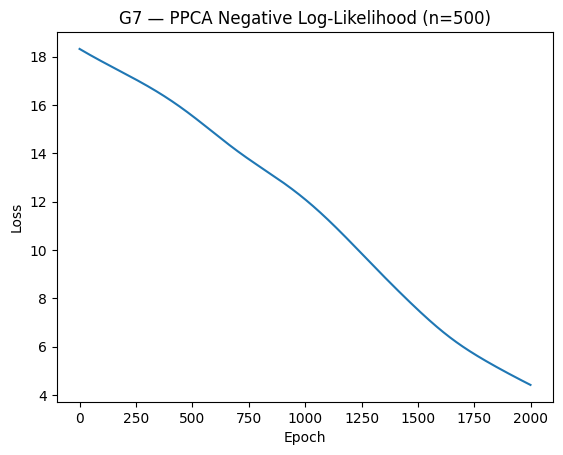


=== G7: PPCA with n=2000 samples ===
Epoch 0000 | Loss = 21.3380
Epoch 0500 | Loss = 17.4835
Epoch 1000 | Loss = 15.5145
Epoch 1500 | Loss = 10.9244
PPCA learned W (first 5 rows):
tensor([[ 0.0571, -0.9367],
        [-0.0653,  1.1135],
        [ 0.2004, -0.4328],
        [-1.1165,  1.8859],
        [ 1.2955,  0.4883]])

PCA components (first 5 rows):
tensor([[-0.2852, -0.0775],
        [ 0.3395,  0.0934],
        [-0.1397,  0.0342],
        [ 0.6139, -0.2482],
        [ 0.1007,  0.5869]])


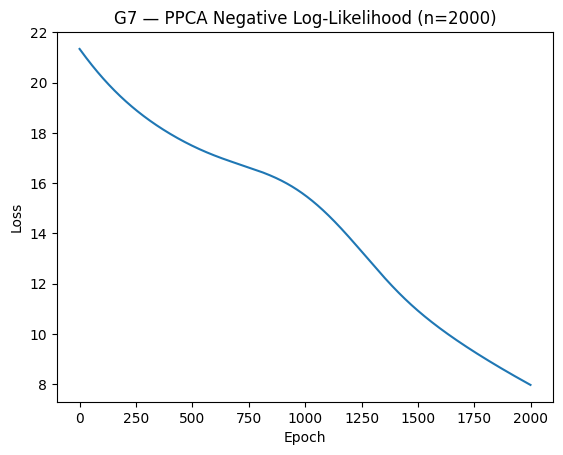


G7 Completed 


In [123]:
# G7: Probabilistic PCA

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


def generate_data(n_samples=500, d=10, k=2):
    """
    Create data with underlying k-dimensional linear structure.
    """
    Z = torch.randn(n_samples, k)
    W_true = torch.randn(d, k)
    noise = 0.1 * torch.randn(n_samples, d)
    X = Z @ W_true.T + noise
    return X


class PPCA(nn.Module):
    def __init__(self, d, k):
        super().__init__()
        self.W = nn.Parameter(torch.randn(d, k))
        self.log_sigma2 = nn.Parameter(torch.tensor(0.0))  # learn noise variance

    def forward(self, X):
        sigma2 = torch.exp(self.log_sigma2)
        C = self.W @ self.W.T + sigma2 * torch.eye(self.W.shape[0])
        dist = torch.distributions.MultivariateNormal(
            loc=torch.zeros(X.shape[1]), covariance_matrix=C
        )
        return -dist.log_prob(X).mean()


def train_ppca(X, k=2, n_epochs=2000, lr=1e-3):
    N, d = X.shape
    ppca = PPCA(d, k)
    opt = optim.Adam(ppca.parameters(), lr=lr)

    losses = []
    for epoch in range(n_epochs):
        opt.zero_grad()
        loss = ppca(X)
        loss.backward()
        opt.step()

        losses.append(loss.item())

        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Loss = {loss.item():.4f}")

    return ppca, losses


def compare_pca_ppca(n_samples=500):
    print(f"\n=== G7: PPCA with n={n_samples} samples ===")
    X = generate_data(n_samples=n_samples)

    ppca, losses = train_ppca(X)

    pca = PCA(n_components=2)
    pca.fit(X.detach().numpy())

    W_ppca = ppca.W.detach()
    W_pca = torch.tensor(pca.components_.T)

    print("PPCA learned W (first 5 rows):")
    print(W_ppca[:5])
    print("\nPCA components (first 5 rows):")
    print(W_pca[:5])

    plt.plot(losses)
    plt.title(f"G7 — PPCA Negative Log-Likelihood (n={n_samples})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    return W_ppca, W_pca, losses


sample_sizes = [50, 100, 500, 2000]
results_g7 = {}

for n in sample_sizes:
    W_ppca, W_pca, losses = compare_pca_ppca(n)
    results_g7[n] = (W_ppca, W_pca, losses)

print("\nG7 Completed ")

In [125]:
# G8: Decision boundary with softmax confidence

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def plot_decision_boundary_with_confidence(model, X, y, title="Decision Boundary + Confidence"):
    model.eval()

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        logits = model(grid_t)
        probs = torch.softmax(logits, dim=1)
        conf, preds = probs.max(dim=1)
        conf = conf.cpu().numpy()
        preds = preds.cpu().numpy()

    conf = conf.reshape(xx.shape)
    preds = preds.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, conf, levels=50, cmap="YlGnBu", alpha=0.8)

    plt.contour(xx, yy, preds, levels=[0.5], colors="k", linewidths=1.5)

    plt.scatter(X[:,0], X[:,1], c=y, cmap=ListedColormap(["#ff6666", "#6666ff"]), edgecolor='k')

    cbar = plt.colorbar()
    cbar.set_label("Softmax Confidence")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

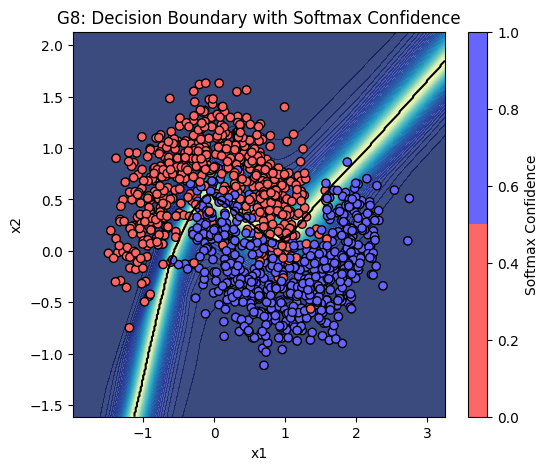

In [ ]:
model_for_G8 = mlp_trained

X_plot = ds_cls.X.cpu().numpy()
y_plot = ds_cls.y.cpu().numpy()

plot_decision_boundary_with_confidence(model_for_G8, X_plot, y_plot,
                                       title="G8: Decision Boundary with Softmax Confidence")


## Mini Project 2 Details


You can get more information [here](https://drive.google.com/drive/folders/1Ckwfj0L788Tg3E6WAazXBB1W2ATta_w9).


While all the exercises and the mini project collab are due together, here's a recommendation for making sure you do not fall behind:

🧠 Mini Project — Recommended Week of Nov 3rd

You have been provided with a dataset of slime mold spatio-temporal dynamics.
Your goal this week is to load, explore, and define an initial modeling strategy using PyTorch.

🧩 Tasks



1.   Load the dataset


*   Identify and use the right Python package to load the data (hint: .zarr format).
*   Write a simple data loader that converts it into a PyTorch tensor.


2.   Visualize the data


*   Plot a few time frames.
*   Describe what you see — what kind of motion or aggregation is happening?



3.   Inspect the data tensor


*   What is the shape of your data?
*   What do each of the dimensions represent?


4.   Define the learning setup

*   Is this a supervised or unsupervised problem?
*   What is your strategy for modeling this data?
(There is no unique answer — justify your choice.)


5.   Specify the optimization target

*   What loss function will you optimize?
*   How will you split your data into training and testing sets?


6.   First modeling attempt

*   Treat this as a nonlinear regression problem.
*   Write a small model class, train it, and visualize the loss landscape.
*   Try one or two variants (e.g. different architectures or window sizes).

📘 Deliverables

Submit a short notebook including:

* Code to load and visualize the data.

* A short discussion of data shape, modeling strategy, and loss.

* Example plots and initial training results.

## 5) TL;DR for your Toolkit!

- **Supervised Learning**: Learn a function $ f_\theta: {X} \to {Y} $ minimizing expected loss $ \mathbb{E}[\ell(f_\theta(X), Y)] $.
- **Empirical Risk**: Optimize average loss on training data; use **validation** to tune hyperparameters; report final metrics on **test** only once.
- **Common losses**: MSE for regression; Cross-Entropy for classification.
- **Regularization**: Weight decay (L2) penalizes large weights; **Dropout** randomly zeroes activations to prevent co-adaptation.
- **Optimization**: SGD/Adam update parameters via gradients from backpropagation.
- **Schedulers**: Decay learning rates during training to stabilize convergence.
- **Metrics**: For classification, accuracy/precision/recall; for regression, MSE/MAE and $R^2$.
- **Reproducibility**: Fix seeds; log versions; control randomness.
